# Train and evaluate the real-PPG vector autoencoder

This is the authoritative V2 experiment. It streams the original Pulse Transit Time PPG ZIP, extracts five-second sensor features every 30 seconds, performs participant-grouped five-fold validation, trains and quantizes the final normal-only autoencoder, evaluates a locked participant holdout, and renders the committed plots.

The model output is binary normal/anomaly after eight-minute aggregation. ECG is validation-only. Endpoint SpO2 is not used as continuous model input.

In [1]:
from pathlib import Path
import contextlib
import io
import json
import os
import sys

os.environ.setdefault('MPLBACKEND', 'Agg')
repo_root = Path.cwd().resolve()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from IPython.display import Image, Markdown, display
from home_health_monitor.datasets.audit import audit_pulse_transit
from home_health_monitor.datasets.pulse_transit_build import build_feature_dataset
from home_health_monitor.gateway.vector_training import train_vector_autoencoder
from home_health_monitor.vector_reporting import build_reconstruction_evidence, render_real_ppg_plots

archive_text = os.environ.get('PULSE_TRANSIT_PPG_ZIP', '')
archive_path = Path(archive_text).expanduser() if archive_text else repo_root / 'data' / 'pulse-transit-time-ppg.zip'
if not archive_path.is_file():
    raise FileNotFoundError('Set PULSE_TRANSIT_PPG_ZIP to the downloaded source ZIP')
work_directory = repo_root / 'notebooks' / '.work'
vectors_path = work_directory / 'real-ppg-features.jsonl'
model_directory = repo_root / 'models' / 'real-ppg-v2'
plot_directory = repo_root / 'docs' / 'assets' / 'real-ppg-v2'
feature_report_path = model_directory / 'feature-extraction-report.json'
work_directory.mkdir(parents=True, exist_ok=True)
SEED = 42
EPOCHS = 30
BATCH_SIZE = 64
print({'archive': archive_path.name, 'seed': SEED, 'epochs': EPOCHS})

{'archive': 'pulse-transit-time-ppg.zip', 'seed': 42, 'epochs': 30}


## Audit and feature extraction

The ZIP is read in place. A complete five-second segment is sampled every 30 seconds to mirror the wearable cadence. Malformed data is recorded and never padded or joined across a gap.

In [2]:
archive_audit = audit_pulse_transit(archive_path)
feature_report = build_feature_dataset(
    archive_path, vectors_path, segment_seconds=5.0, stride_seconds=30.0
)
feature_report_path.write_text(
    json.dumps(feature_report, indent=2, sort_keys=True) + '\n', encoding='utf-8'
)
print(json.dumps({
    'participants': archive_audit.participant_count,
    'recordings': archive_audit.recording_count,
    'feature_vectors': feature_report['feature_rows'],
    'heart_rate_valid_fraction': feature_report['heart_rate_valid_fraction'],
    'ppg_vs_ecg_mae_bpm': feature_report['ppg_vs_ecg_heart_rate']['mae_bpm'],
    'continuous_spo2_available': archive_audit.feature_availability['spo2_percent'],
}, indent=2))

{
  "participants": 22,
  "recordings": 66,
  "feature_vectors": 1112,
  "heart_rate_valid_fraction": 0.6960431654676259,
  "ppg_vs_ecg_mae_bpm": 1.8057733025703384,
  "continuous_spo2_available": false
}


## Participant-grouped training and quantized evaluation

No participant appears in both sides of a fold. Four participants are locked before cross-validation and opened once for final healthy-data evaluation. Thresholds come from quantized out-of-fold eight-minute scores.

In [3]:
training_log = io.StringIO()
with contextlib.redirect_stdout(training_log), contextlib.redirect_stderr(training_log):
    metadata = train_vector_autoencoder(
        vectors_path, model_directory, epochs=EPOCHS, batch_size=BATCH_SIZE, seed=SEED
    )
training_report_path = model_directory / 'training-report.json'
training_report = json.loads(training_report_path.read_text(encoding='utf-8'))
print(json.dumps({
    'model_id': metadata['model_id'],
    'model_size_bytes': metadata['model_size_bytes'],
    'persistent_threshold': metadata['thresholds']['persistent_error'],
    'locked_healthy_intervals': training_report['locked_normal_test']['interval_summary'],
    'controlled_sensitivity': {
        name: item['summary']['anomaly_fraction']
        for name, item in training_report['controlled_sensitivity'].items()
    },
}, indent=2))

W0000 00:00:1790260036.791385  753399 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790260036.791396  753399 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790260036.791589  753399 reader.cc:83] Reading SavedModel from: /var/folders/l7/m3wgz92x6vj1gkr9lwh0893c0000gq/T/tmpds0jhe59
I0000 00:00:1790260036.791895  753399 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1790260036.791899  753399 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/l7/m3wgz92x6vj1gkr9lwh0893c0000gq/T/tmpds0jhe59
I0000 00:00:1790260036.794062  753399 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1790260036.794423  753399 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1790260036.807903  753399 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/l7/m3wgz92x6vj1gkr9lwh0893c0000gq/T/tmpds0jhe59
I0000 00:00:1790260036.812191  753399 lo

{
  "model_id": "real-ppg-vector-ae-656b0bbe66fe",
  "model_size_bytes": 4288,
  "persistent_threshold": 2.4260962653160063,
  "locked_healthy_intervals": {
    "anomaly_fraction": 0.0,
    "count": 12,
    "maximum": 1.8091919422149656,
    "mean": 0.9665182709693904,
    "median": 0.8677713453769682,
    "minimum": 0.35749195814132656,
    "p95": 1.584038760662078
  },
  "controlled_sensitivity": {
    "combined_drift": 1.0,
    "heart_rate_shift": 0.9166666666666666,
    "motion_shift": 1.0,
    "temperature_shift": 0.5
  }
}


W0000 00:00:1790260045.652171  753399 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1790260045.652181  753399 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1790260045.652281  753399 reader.cc:83] Reading SavedModel from: /var/folders/l7/m3wgz92x6vj1gkr9lwh0893c0000gq/T/tmpwq74vql0
I0000 00:00:1790260045.652556  753399 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1790260045.652560  753399 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/l7/m3wgz92x6vj1gkr9lwh0893c0000gq/T/tmpwq74vql0
I0000 00:00:1790260045.654832  753399 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1790260045.668297  753399 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/l7/m3wgz92x6vj1gkr9lwh0893c0000gq/T/tmpwq74vql0
I0000 00:00:1790260045.672573  753399 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 20295 microseconds.
fully_quantize: 0, in

## Figures

/Users/sam/Documents/home-health-monitor/.venv-train/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:465: UserWarning: Warning: Enabling `experimental_preserve_all_tensors` with the BUILTIN or AUTO op resolver is intended for debugging purposes only. Be aware that this can significantly increase memory usage by storing all intermediate tensors. If you encounter memory problems or are not actively debugging, consider disabling this option.
  warnings.warn(


### Ppg Heart Rate Validation

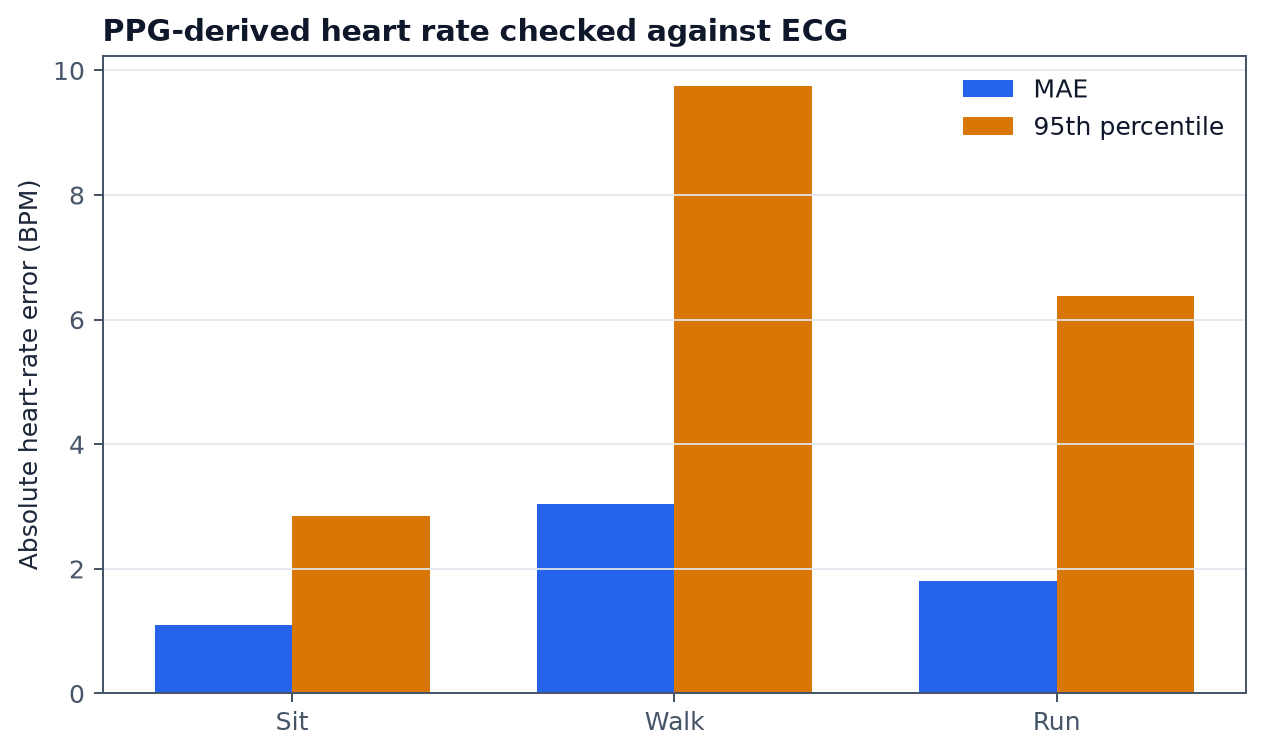

### Real Ppg Actual Vs Reconstructed

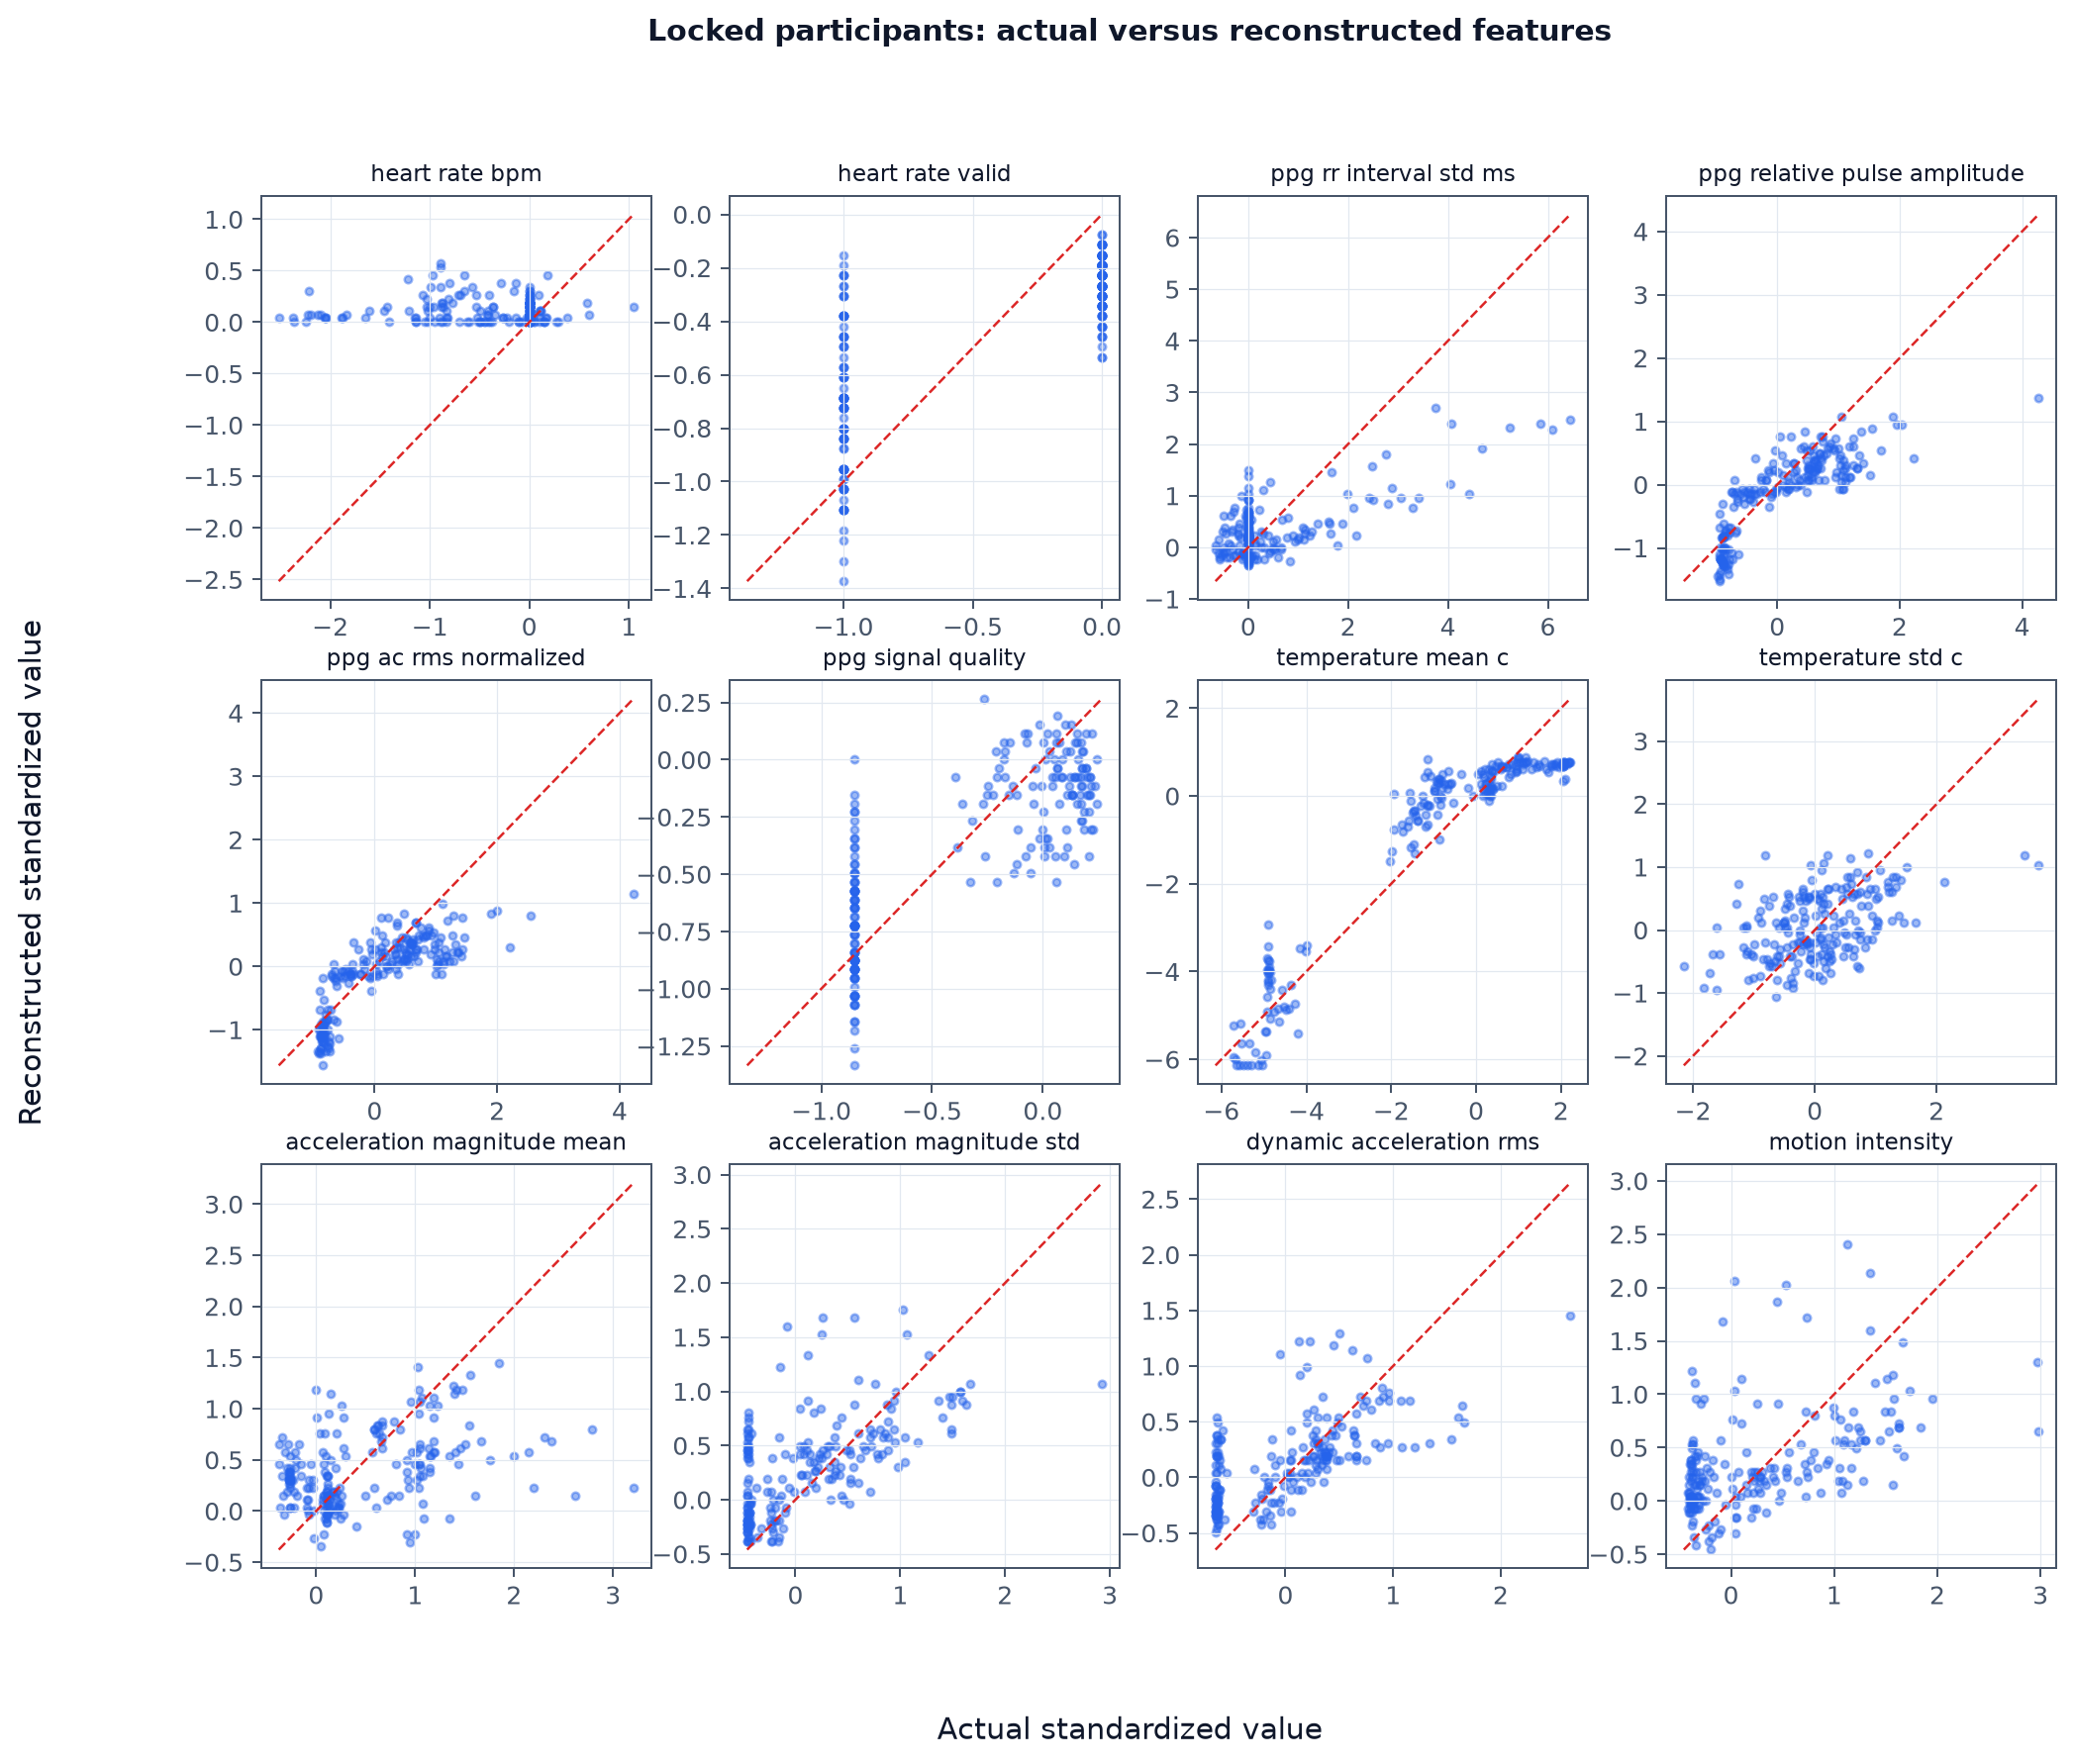

### Real Ppg Reconstruction Error By Feature

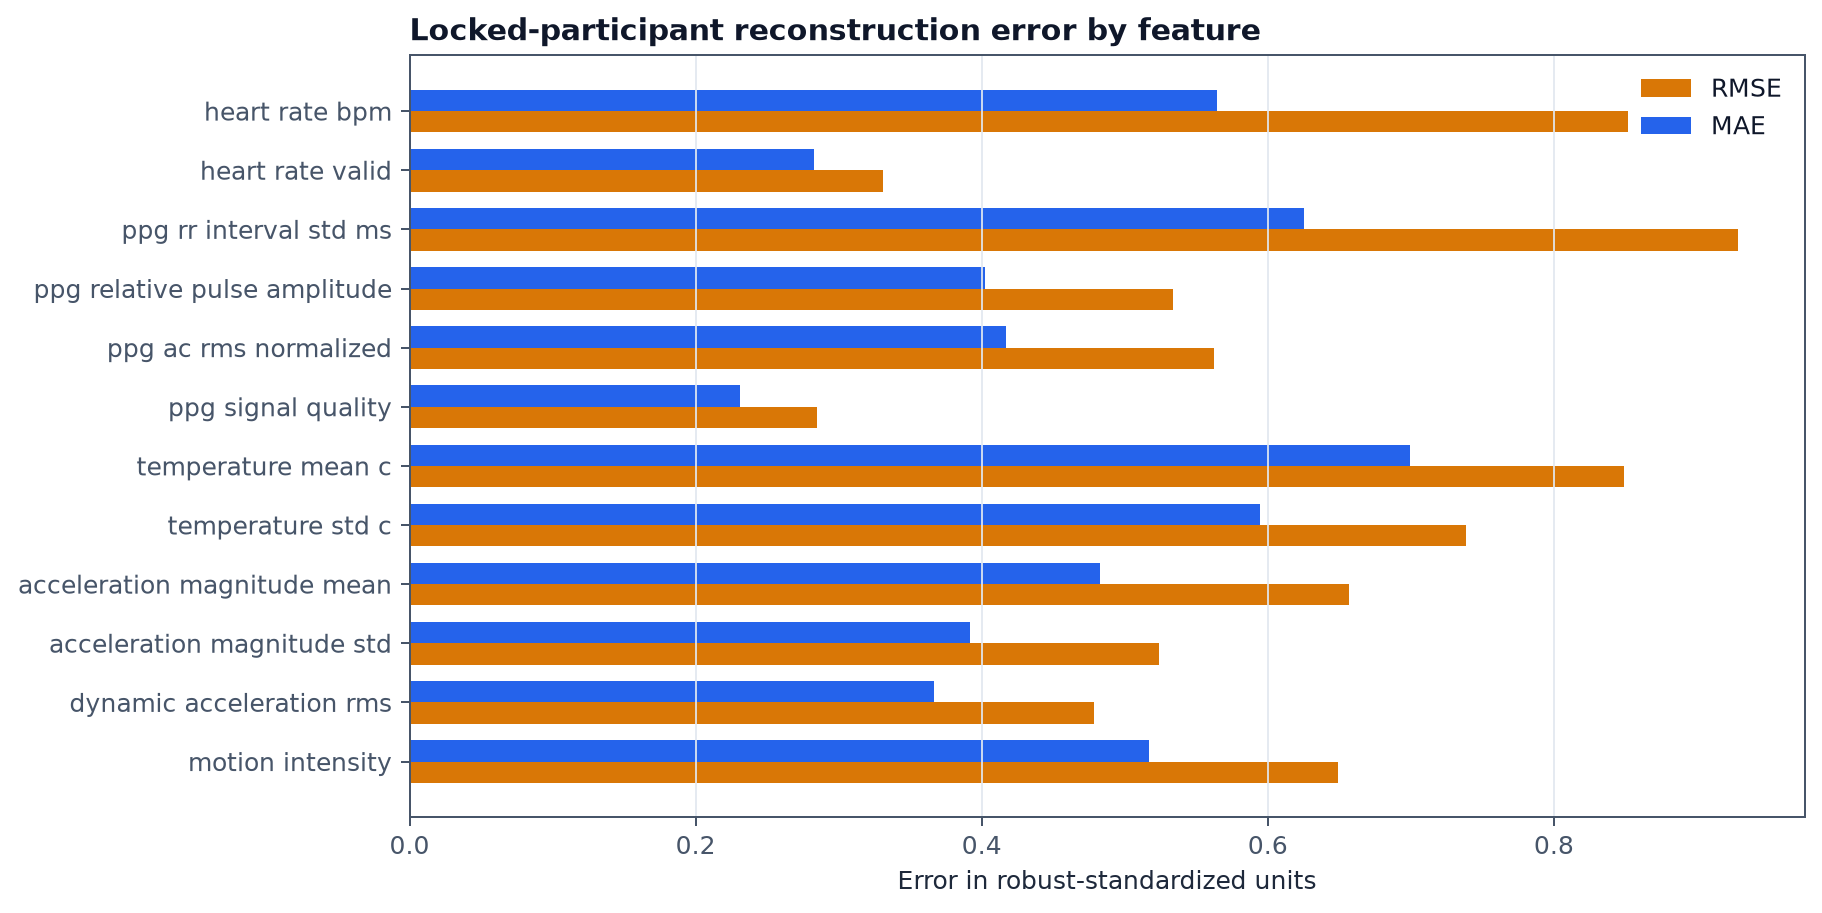

### Real Ppg Reconstruction Examples

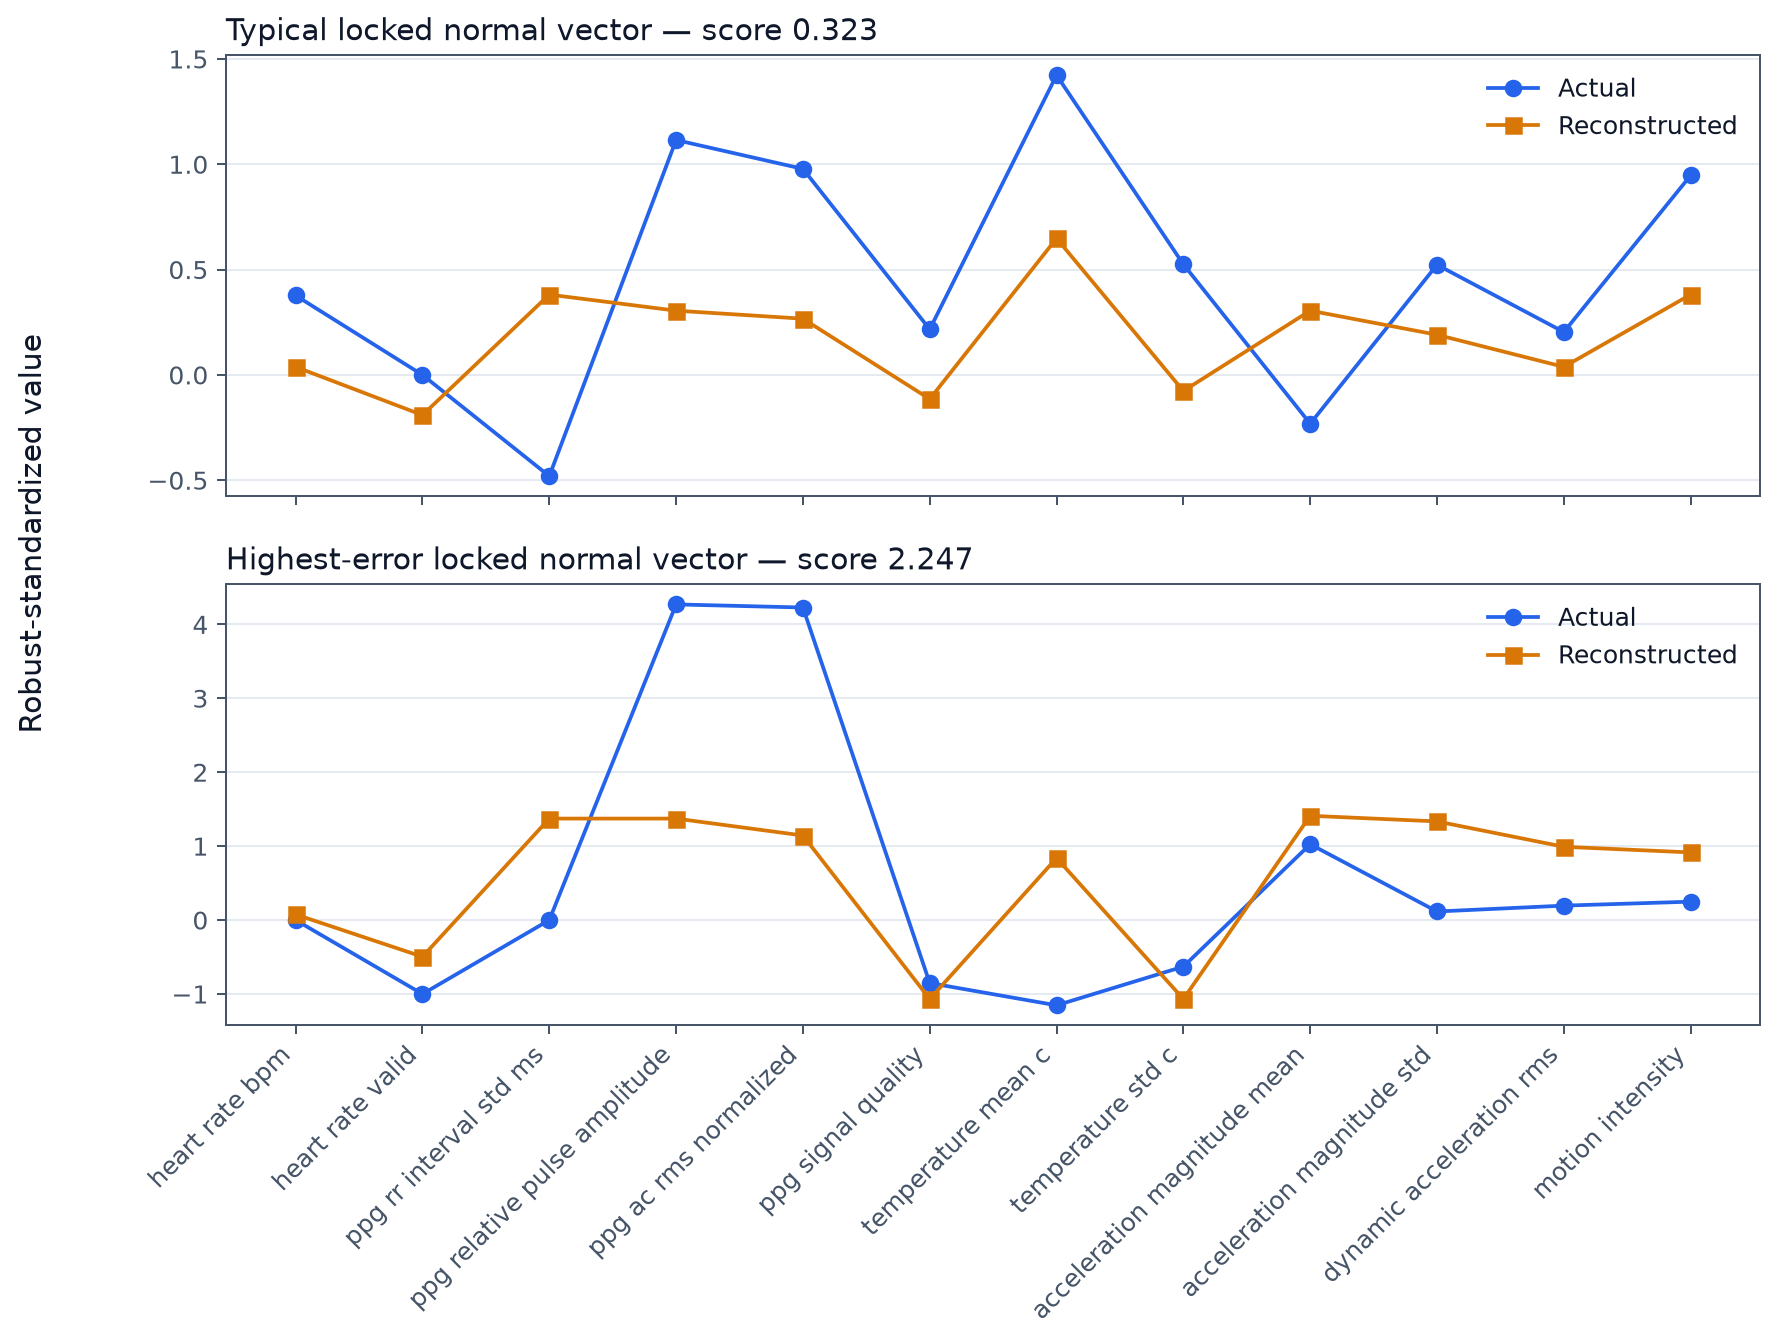

### Real Ppg Normal Vs Controlled Residuals

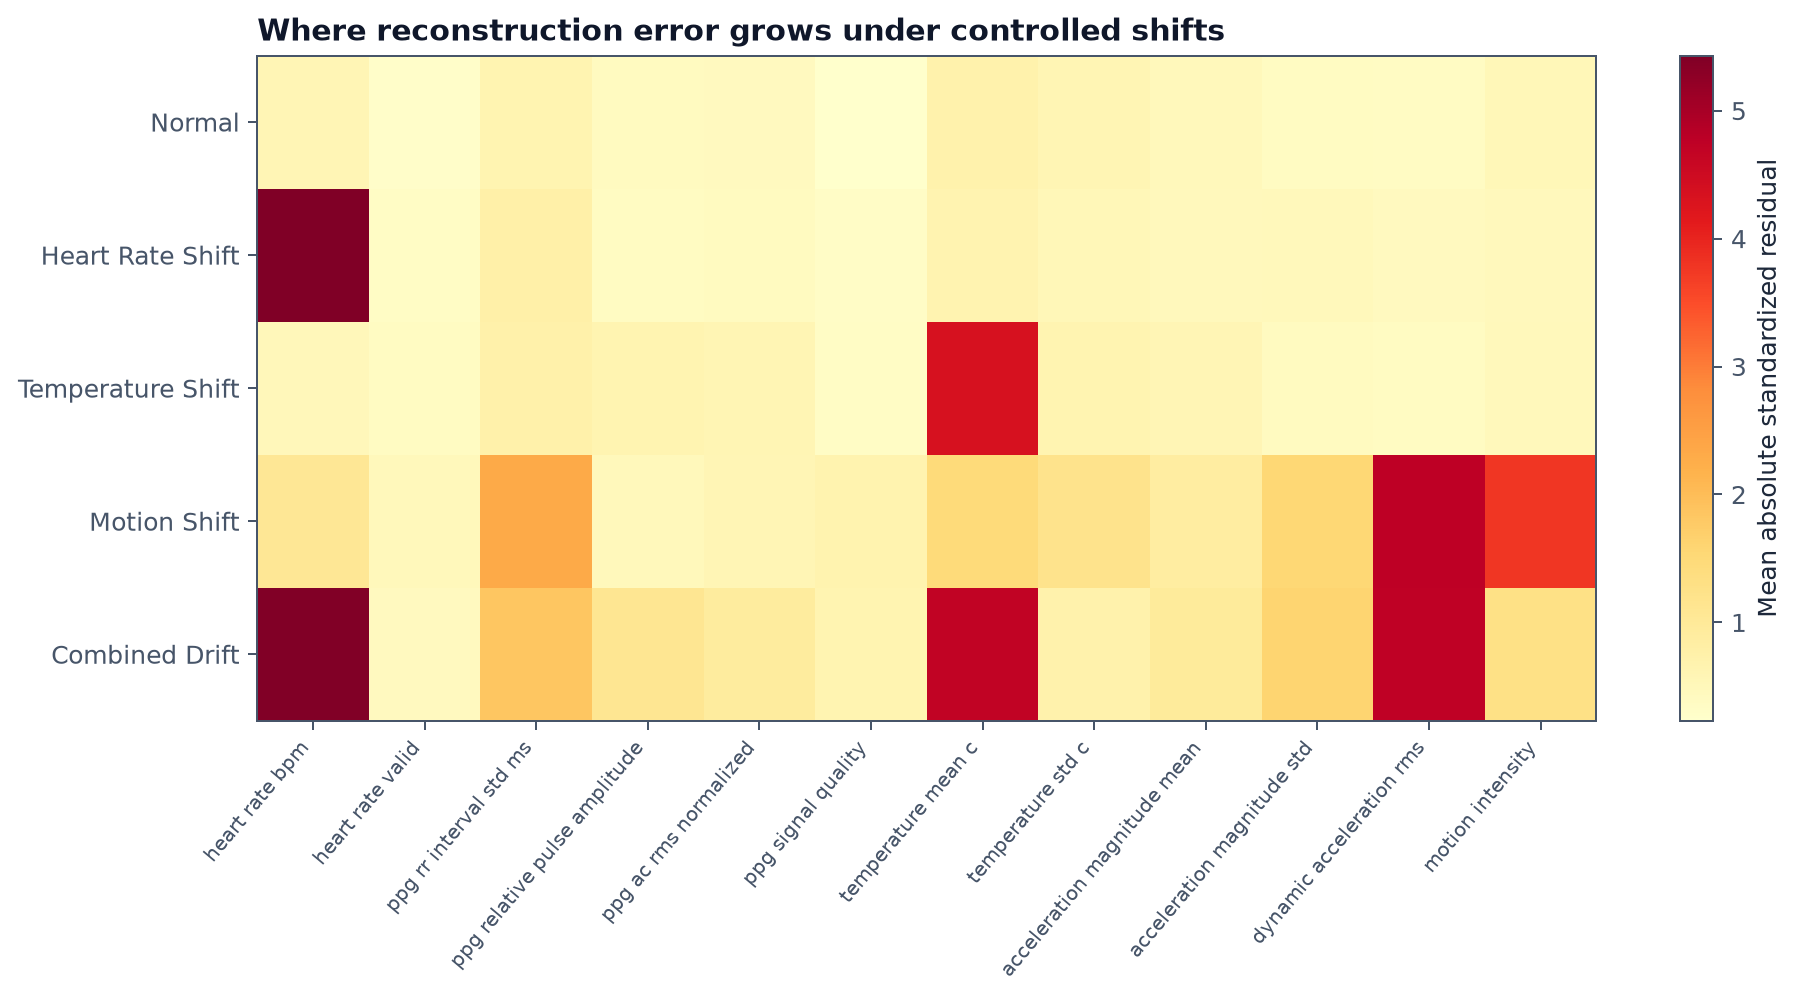

### Real Ppg Training Loss

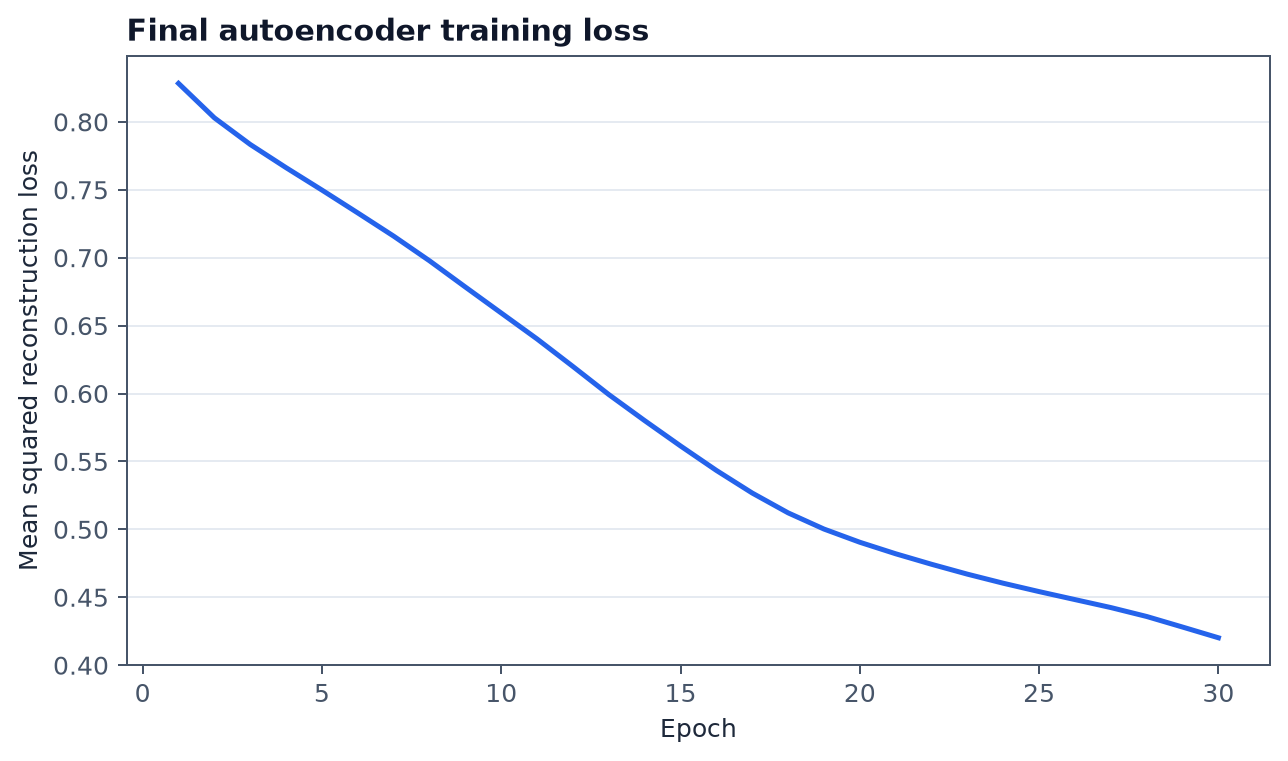

### Real Ppg Normal Score Distribution

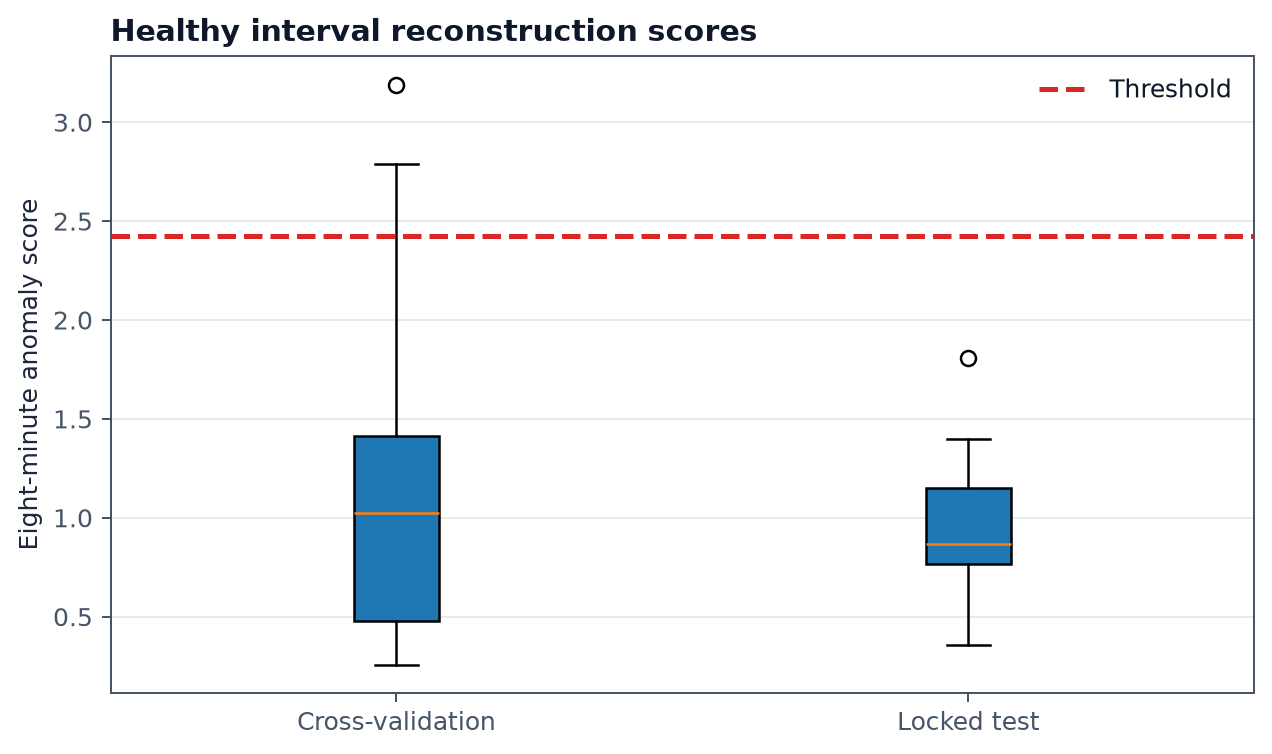

### Real Ppg False Anomalies By Activity

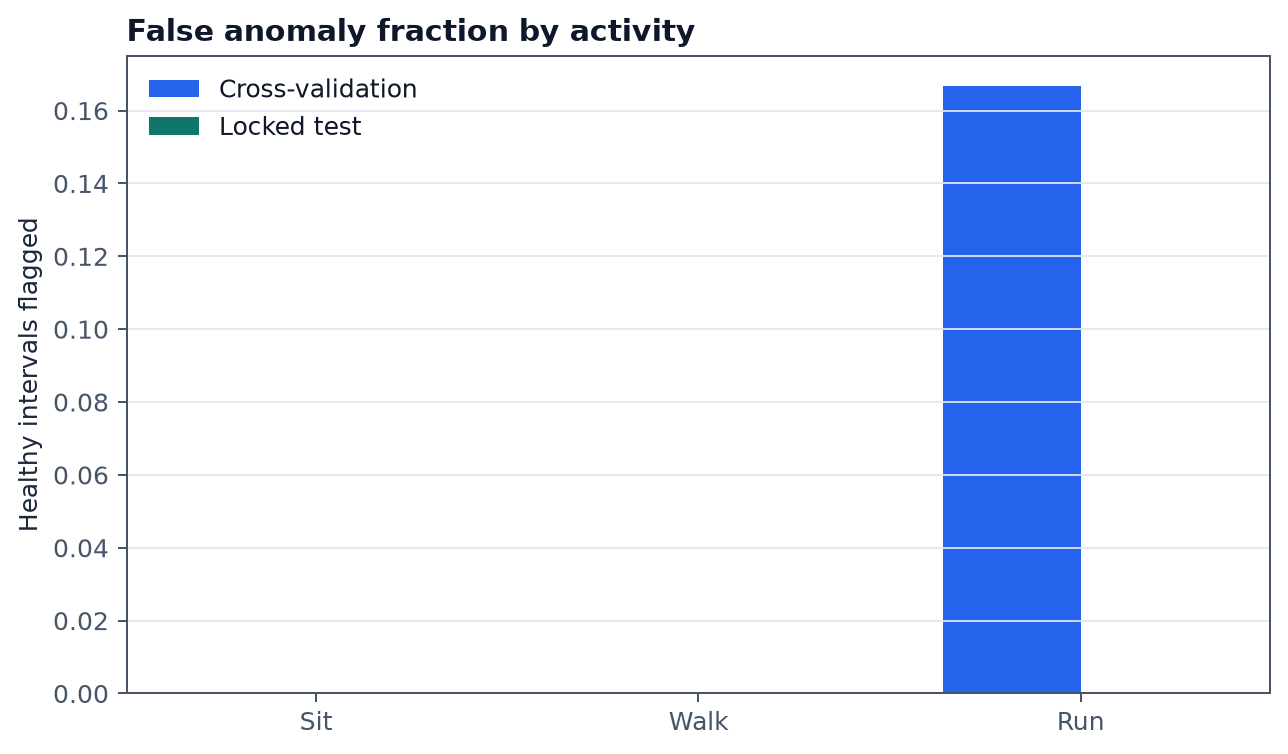

### Real Ppg Controlled Sensitivity

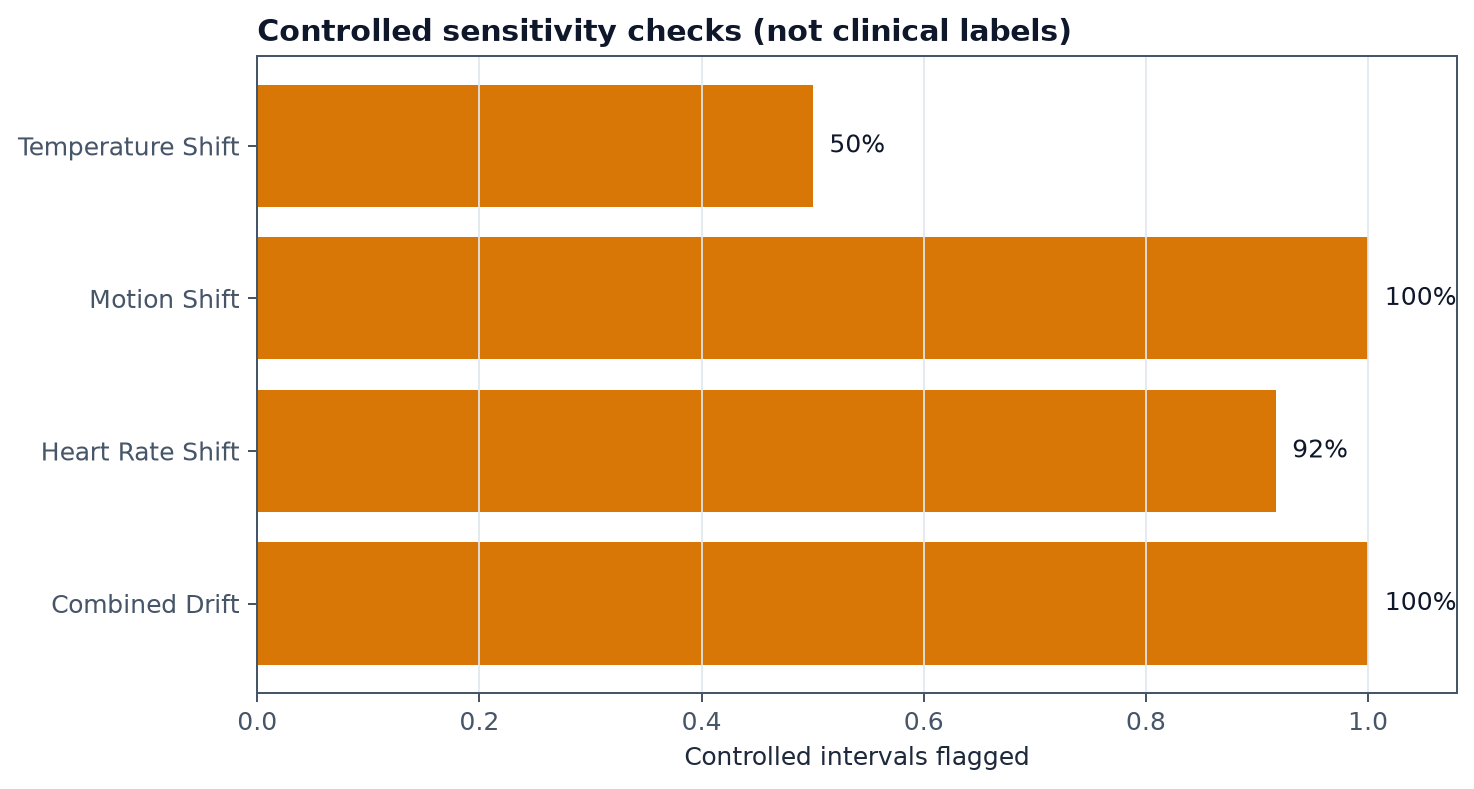

### Real Ppg Feature Correlation

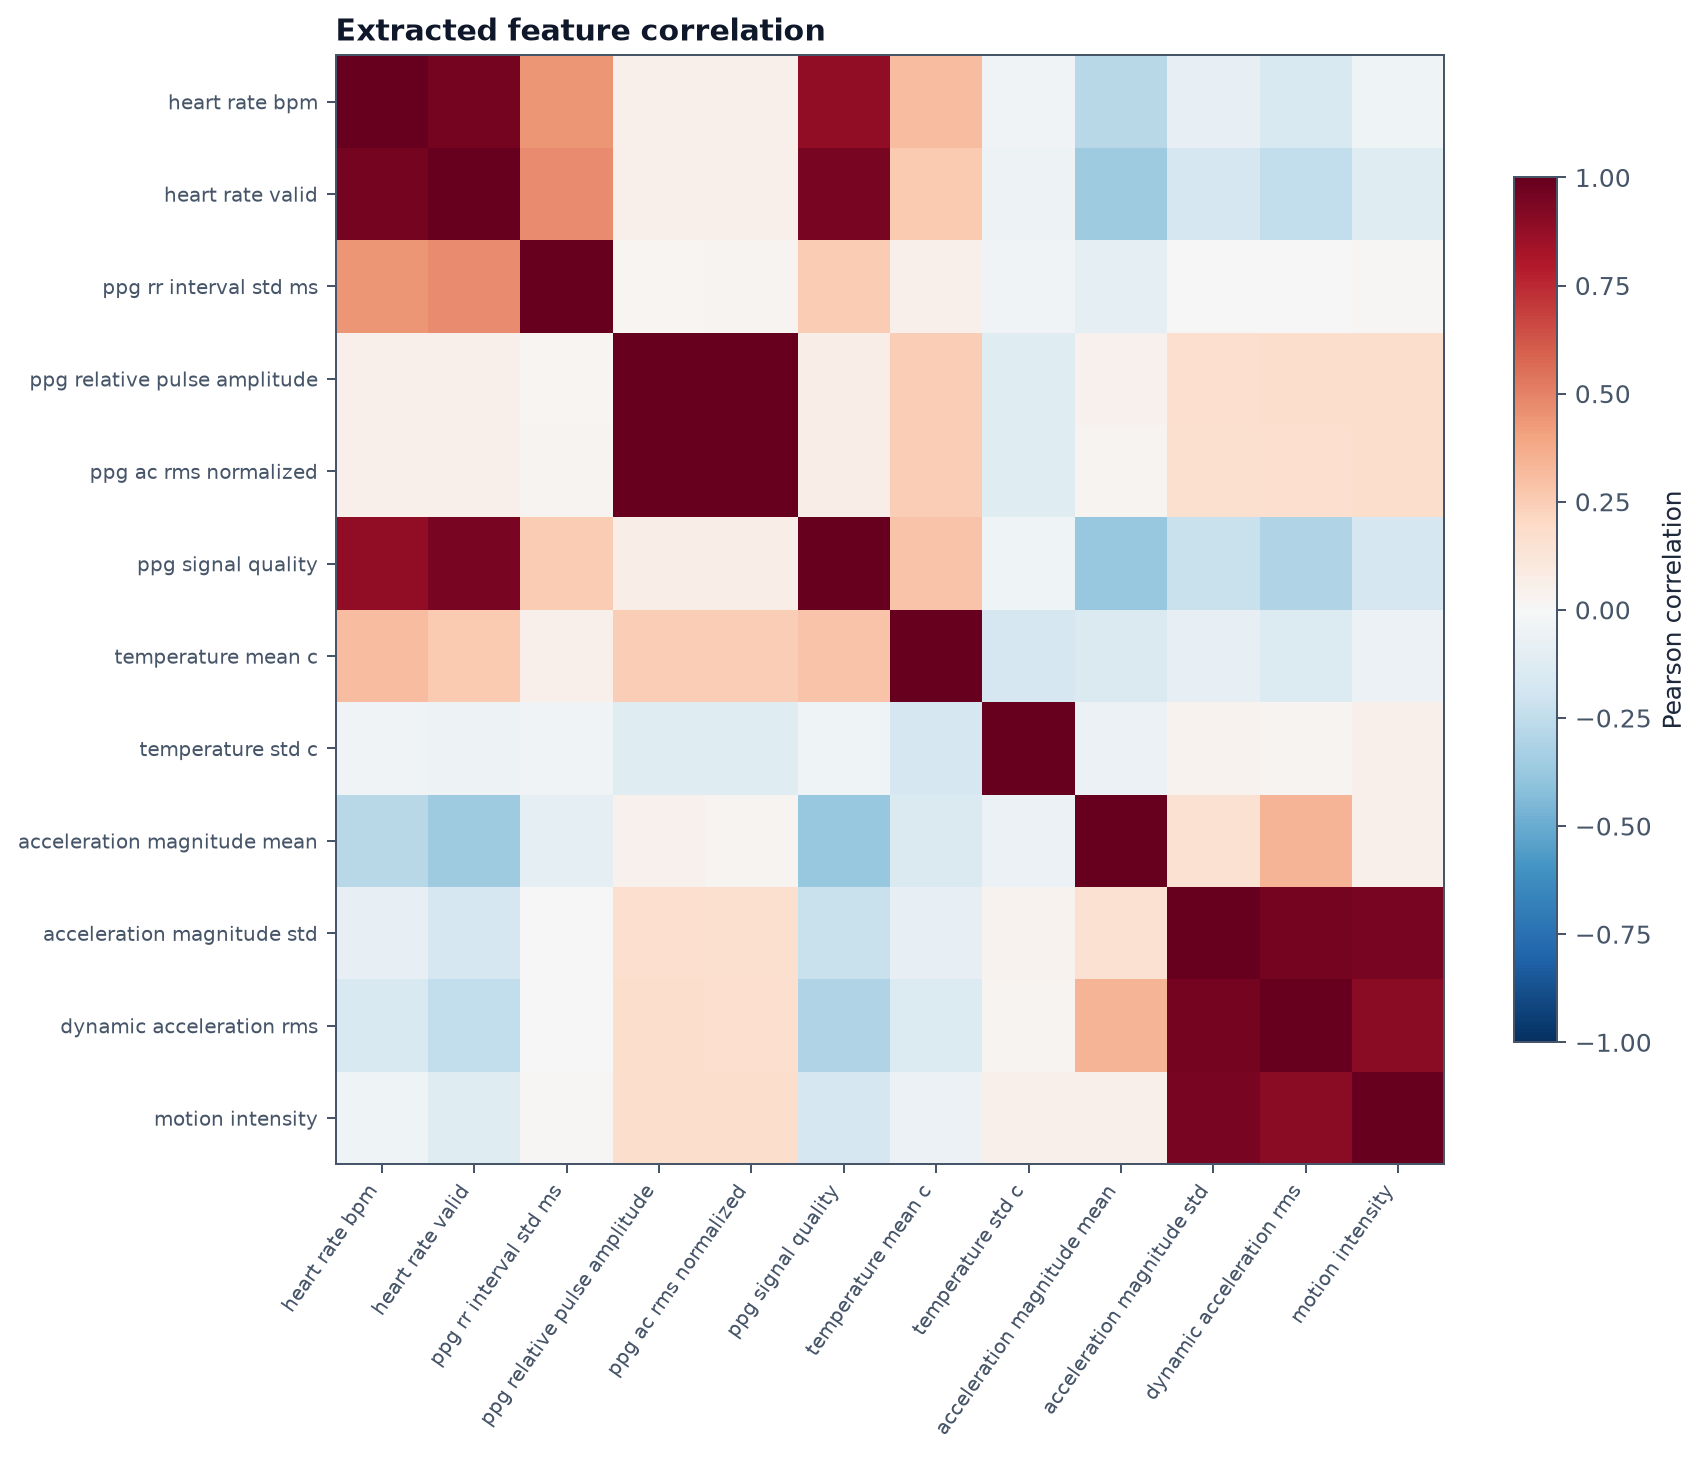

In [4]:
reconstruction_evidence_path = build_reconstruction_evidence(
    training_report_path, vectors_path, model_directory / 'model.tflite',
    model_directory / 'model-metadata.json', model_directory / 'reconstruction-evaluation.json'
)
plot_paths = render_real_ppg_plots(
    feature_report_path, training_report_path, vectors_path, plot_directory,
    reconstruction_evidence_path
)
for plot_path in plot_paths:
    display(Markdown(f'### {plot_path.stem.replace("-", " ").title()}'))
    display(Image(filename=str(plot_path)))

## Interpretation

- The artifact is a real-data development candidate installed on its own V2 endpoint; V1 remains the complete/default wearable route.
- Actual-versus-reconstructed figures use only the four locked participants and the committed int8 model.
- Values are shown in robust-standardized units so all 12 differently scaled features can be compared fairly.
- The locked set contains healthy recordings, so it measures false anomalies, not disease sensitivity.
- Controlled shifts test expected direction only and are not clinical labels.
- Temperature-only sensitivity is weaker than heart-rate and motion sensitivity; the personal-baseline tier therefore remains essential.
- Continuous SpO2 and the exact wearable 20-feature BLE formulas are still required before this candidate can replace V1.